In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import math
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
import scipy.stats as stats

C:\Users\jymbc\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\jymbc\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
file_read_path = r'F:\SMAD PROJECT\Macrophage_reanalysis\multiome\data'

file_save_path = r'F:\SMAD PROJECT\Macrophage_reanalysis\multiome\files'

figure_save_path = r'F:\SMAD PROJECT\Macrophage_reanalysis\multiome\figures'

In [7]:
df = pd.read_csv(f'{file_save_path}/all_proteins_after_SSnormalization.csv',index_col = 0)

In [8]:
df

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
1/sp|B2RXS4|PLXB2_MOUSE,-0.822880,-0.873890,-0.670806,-0.542887,-0.748379,-0.851547,-0.801583,-0.827870,-0.790689,-0.746372,...,-0.802655,-0.947154,-0.818817,-1.098492,-0.660528,-0.804867,-0.561072,-0.877808,-0.889746,-0.853838
1/sp|E9Q634|MYO1E_MOUSE,-0.871106,-0.962441,-0.937897,-0.858373,-0.989953,-0.977299,-0.982300,-0.822409,-0.857692,-1.041580,...,-0.969096,-1.009366,-0.900187,-1.057397,-1.031484,-0.937807,-0.896148,-0.945061,-0.946866,-0.906603
1/sp|O08529|CAN2_MOUSE,0.261779,0.169324,0.273492,0.178511,0.338167,0.245746,-0.032840,0.009486,-0.002325,0.014372,...,0.115555,0.121304,0.059028,0.193572,0.113388,0.183499,0.218382,0.212425,0.107759,0.152039
1/sp|O08553|DPYL2_MOUSE,1.037415,0.936371,0.962614,0.933773,1.049204,0.987733,0.946450,0.855687,0.910354,0.866045,...,0.832558,0.972378,0.959039,0.841880,0.847812,0.953970,1.094917,1.077061,0.993882,0.983324
1/sp|O08749|DLDH_MOUSE,-0.254792,-0.141971,-0.310627,-0.243267,-0.369222,-0.419146,-0.142676,-0.094446,-0.131789,-0.042683,...,-0.230182,-0.283645,-0.186616,-0.208966,-0.050865,0.054585,-0.142583,-0.102815,-0.173362,-0.027716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7/sp|Q8CBW3|ABI1_MOUSE/tr|B7ZCU0|B7ZCU0_MOUSE/tr|B7ZCU2|B7ZCU2_MOUSE/tr|B7ZCU3|B7ZCU3_MOUSE/tr|B7ZCU4|B7ZCU4_MOUSE/tr|B7ZCU5|B7ZCU5_MOUSE/tr|J3QNK8|J3QNK8_MOUSE,-1.323264,-1.026674,-1.104725,-1.047597,-1.049829,-0.779773,-1.095233,-1.087548,-1.330504,-0.942354,...,-0.975997,-1.072443,-1.016691,-1.237151,-1.030347,-1.138374,-1.130498,-1.286832,-1.079564,-1.047130
7/sp|Q9CZY3|UB2V1_MOUSE/sp|Q9D2M8|UB2V2_MOUSE/tr|A6X925|A6X925_MOUSE/tr|B2KF55|B2KF55_MOUSE/tr|B7ZBY6|B7ZBY6_MOUSE/tr|B7ZBY7|B7ZBY7_MOUSE/tr|E9PY39|E9PY39_MOUSE,-0.005656,0.010955,-0.013404,-0.013398,0.093140,-0.055802,-0.307661,-0.233921,-0.304716,-0.210242,...,0.032534,-0.086047,-0.125613,0.031755,-0.138541,-0.199608,-0.147505,-0.195665,-0.127073,0.010760
9/sp|P10853|H2B1F_MOUSE/sp|P10854|H2B1M_MOUSE/sp|Q64475|H2B1B_MOUSE/sp|Q64478|H2B1H_MOUSE/sp|Q64525|H2B2B_MOUSE/sp|Q6ZWY9|H2B1C_MOUSE/sp|Q8CGP1|H2B1K_MOUSE/sp|Q8CGP2|H2B1P_MOUSE/tr|Q8CBB6|Q8CBB6_MOUSE,3.133748,2.994868,3.052889,2.984624,3.124791,3.013890,3.127235,3.245112,3.067320,3.205458,...,3.155167,3.090217,3.076423,3.029883,3.094961,2.950504,2.935518,3.014644,3.106077,2.955323
9/sp|P15379|CD44_MOUSE/tr|A2APM1|A2APM1_MOUSE/tr|A2APM2|A2APM2_MOUSE/tr|A2APM3|A2APM3_MOUSE/tr|A2APM4|A2APM4_MOUSE/tr|A2APM5|A2APM5_MOUSE/tr|E9QKM8|E9QKM8_MOUSE/tr|Q3U8S1|Q3U8S1_MOUSE/tr|Q80X37|Q80X37_MOUSE,-0.768139,-0.779036,-0.776722,-0.811212,-0.799782,-0.813013,-0.262929,-0.611110,-0.579372,-0.706905,...,-0.597038,-0.628780,-0.557624,-0.566616,-1.103253,-0.980123,-0.882229,-0.774231,-0.827672,-1.047394


In [42]:
df.index.name = 'protein_groups'

In [44]:
df[df.index.str.contains('HMOX')]

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
protein_groups,,,,,,,,,,,,,,,,,,,,,
1/sp|P14901|HMOX1_MOUSE,-0.849814,-0.768719,-1.131110,-0.480346,-1.055589,-1.002559,-0.876415,-0.966066,-0.906534,-0.915236,...,-1.351909,-1.202987,-1.341944,-1.210186,-0.782861,-0.343597,-0.888404,-0.720384,-0.460557,-0.368041
3/sp|O70252|HMOX2_MOUSE/tr|D3YX62|D3YX62_MOUSE/tr|D3YXN4|D3YXN4_MOUSE,-0.568928,-0.664721,-0.675019,-0.706960,-0.590168,-0.594541,-0.563259,-0.482144,-0.637629,-0.436173,...,-0.622428,-0.557726,-0.663446,-0.500926,-0.457329,-0.252595,-0.470998,-0.567232,-0.505609,-0.518155


In [45]:
selected_df = df[df.index.str.contains('HMOX1', case=False, na=False)]   

In [46]:
selected_df

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
protein_groups,,,,,,,,,,,,,,,,,,,,,
1/sp|P14901|HMOX1_MOUSE,-0.849814,-0.768719,-1.13111,-0.480346,-1.055589,-1.002559,-0.876415,-0.966066,-0.906534,-0.915236,...,-1.351909,-1.202987,-1.341944,-1.210186,-0.782861,-0.343597,-0.888404,-0.720384,-0.460557,-0.368041


In [47]:
selected_df.reset_index().melt(id_vars='protein_groups', var_name='Sample', value_name='Expression')   

,protein_groups,Sample,Expression
0,1/sp|P14901|HMOX1_MOUSE,A1,-0.849814
1,1/sp|P14901|HMOX1_MOUSE,A2,-0.768719
2,1/sp|P14901|HMOX1_MOUSE,A3,-1.131110
3,1/sp|P14901|HMOX1_MOUSE,A4,-0.480346
4,1/sp|P14901|HMOX1_MOUSE,A5,-1.055589
5,1/sp|P14901|HMOX1_MOUSE,A6,-1.002559
6,1/sp|P14901|HMOX1_MOUSE,B1,-0.876415
7,1/sp|P14901|HMOX1_MOUSE,B2,-0.966066
8,1/sp|P14901|HMOX1_MOUSE,B3,-0.906534
9,1/sp|P14901|HMOX1_MOUSE,B4,-0.915236


In [50]:
figure_save_path2 = r'F:\SMAD PROJECT\Macrophage_reanalysis\multiome\figures'


def boxplot_gene2(Gene_name = "Trem2",df_select_pro = df):
    
    plt.rcParams['font.family'] = 'Arial'
    # Assuming `df` is your DataFrame with proteins as index
    # Define the mapping of columns to treatments
    treatment_map = {'A': 'Con', 'B': 'LPS', 'C': 'IL-4', 'D': 'IRD' }
    # Select proteins whose index contains "RBM8A"
    selected_df = df_select_pro[df_select_pro.index.str.contains(Gene_name, case=False, na=False)]    
    # Melt the dataframe to long format for seaborn
    df_long = selected_df.reset_index().melt(id_vars='protein_groups', var_name='Sample', value_name='Expression')    
    # Extract the treatment group from column names
    df_long['Treatment'] = (df_long['Sample'].str[0].map(treatment_map))
    
    desired_order = ['Con', 'LPS', 'IL-4', 'IRD']  # adjust as needed
    # Plot box-strip plot
    plt.figure(figsize=(7, 6.5))
    sns.boxplot(x='Treatment', y='Expression',order=desired_order,  data=df_long, showfliers=False, width=0.8)
    sns.stripplot(x='Treatment', y='Expression',order=desired_order,  data=df_long, jitter=True, color='black', alpha=0.7,size=10)    
    # Improve plot aesthetics
    plt.gca().locator_params(axis='y', nbins=4)
    plt.xticks(rotation=45,fontsize = 28)
    plt.yticks(fontsize = 28)
    plt.xlabel("",fontsize = 28)
    plt.ylabel("Expression level(Z-score)",fontsize = 28)
    plt.title(f"smad_{Gene_name}",fontsize = 20)
    # plt.savefig(f'{figure_save_path}/RBM8A.svg', dpi=800, bbox_inches='tight')
    plt.savefig(f'{figure_save_path2}/smad_{Gene_name}.svg', dpi=800, bbox_inches='tight')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

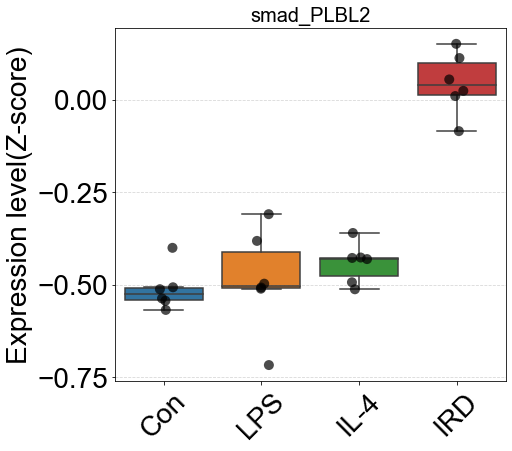

In [54]:
boxplot_gene2(Gene_name = "PLBL2",df_select_pro = df)

In [13]:
# function for oneway_ANOVA analysis 
def oneway_ANOVA_Ttest(result):
    pval=[]
    for i in range(len(result)):
        aa=result.iloc[i,:6].tolist()
        bb=result.iloc[i,6:12].tolist()
        cc=result.iloc[i,12:18].tolist()
        dd=result.iloc[i,18:24].tolist()
        p_value_anova = f_oneway(aa,bb,cc,dd)[1]
        p_value_ttest = stats.ttest_ind(aa, dd)[1]  # Welch’s t-test
        pval.append([result.index[i],p_value_anova,p_value_ttest])
        fl = pd.DataFrame(pval)
        fl.columns = ['protein', 'p_value_anova','p_value_ttest(Con-IRD)']
    return(fl)

In [14]:
dfpro_pval = oneway_ANOVA_Ttest(result=df)

In [18]:
pval = dfpro_pval.set_index('protein')

In [20]:
pval[pval.index.str.contains('HMOX')]

,p_value_anova,p_value_ttest(Con-IRD)
protein,,
1/sp|P14901|HMOX1_MOUSE,0.000026,0.060125
3/sp|O70252|HMOX2_MOUSE/tr|D3YX62|D3YX62_MOUSE/tr|D3YXN4|D3YXN4_MOUSE,0.017079,0.006644


In [23]:
def get_mean_macrophage_dataset(df):
    '''input is a 24 columns dataset and every 6 columns is a treatment'''

    con=df.iloc[:,:6].mean(axis=1).tolist()
    lps=df.iloc[:,6:12].mean(axis=1).tolist()
    IL_4=df.iloc[:,12:18].mean(axis=1).tolist()
    IRD=df.iloc[:,18:24].mean(axis=1).tolist()
    newdict={'Con':con,'LPS':lps,'IL_4':IL_4,'IRD':IRD}
    
    df_mean=pd.DataFrame.from_dict(newdict)
    df_mean.index=df.index
    return df_mean

In [25]:
mean_df = get_mean_macrophage_dataset(df)

In [27]:
mean_df['p_value_anova'] = pval['p_value_anova']
mean_df['p_value_ttest(Con-IRD)'] = pval['p_value_ttest(Con-IRD)']

In [30]:
from statsmodels.stats.multitest import multipletests

# run FDR correction
reject, pvals_anova_corrected, _, _ = multipletests(
    mean_df['p_value_anova'], 
    alpha=0.05, 
    method='fdr_bh'
)

reject, pvals_ttest_corrected, _, _ = multipletests(
    mean_df['p_value_ttest(Con-IRD)'], 
    alpha=0.05, 
    method='fdr_bh'
)

mean_df['p_anova_adj']      = pvals_anova_corrected

mean_df['p_ttest_adj']      = pvals_ttest_corrected


In [55]:
mean_df[mean_df.index.str.contains('PLBL2')]

,Con,LPS,IL_4,IRD,p_value_anova,p_value_ttest(Con-IRD),p_anova_adj,p_ttest_adj
protein_groups,,,,,,,,
1/sp|Q3TCN2|PLBL2_MOUSE,-0.511089,-0.487041,-0.441588,0.044506,1.446566e-09,1.037988e-07,3.368976e-08,0.000009


In [33]:
mean_df.to_csv(f'{file_save_path}/macro_proteomics_summary_SMAD.csv')

In [34]:
mean_df

,Con,LPS,IL_4,IRD,p_value_anova,p_value_ttest(Con-IRD),p_anova_adj,p_ttest_adj
1/sp|B2RXS4|PLXB2_MOUSE,-0.751732,-0.783681,-0.901124,-0.774643,0.116796,0.766984,0.155425,0.852739
1/sp|E9Q634|MYO1E_MOUSE,-0.932845,-0.964184,-0.936204,-0.943995,0.928914,0.717326,0.934192,0.810771
1/sp|O08529|CAN2_MOUSE,0.244503,0.017315,0.080652,0.164582,0.000011,0.033238,0.000064,0.085760
1/sp|O08553|DPYL2_MOUSE,0.984518,0.911122,0.919098,0.991828,0.106345,0.864787,0.143757,0.911631
1/sp|O08749|DLDH_MOUSE,-0.289838,-0.131881,-0.203156,-0.073793,0.000657,0.002148,0.002009,0.012368
...,...,...,...,...,...,...,...,...
7/sp|Q8CBW3|ABI1_MOUSE/tr|B7ZCU0|B7ZCU0_MOUSE/tr|B7ZCU2|B7ZCU2_MOUSE/tr|B7ZCU3|B7ZCU3_MOUSE/tr|B7ZCU4|B7ZCU4_MOUSE/tr|B7ZCU5|B7ZCU5_MOUSE/tr|J3QNK8|J3QNK8_MOUSE,-1.055310,-1.100458,-1.062265,-1.118791,0.792936,0.448555,0.810333,0.583782
7/sp|Q9CZY3|UB2V1_MOUSE/sp|Q9D2M8|UB2V2_MOUSE/tr|A6X925|A6X925_MOUSE/tr|B2KF55|B2KF55_MOUSE/tr|B7ZBY6|B7ZBY6_MOUSE/tr|B7ZBY7|B7ZBY7_MOUSE/tr|E9PY39|E9PY39_MOUSE,0.002639,-0.240202,-0.027602,-0.132939,0.000191,0.004519,0.000717,0.020615
9/sp|P10853|H2B1F_MOUSE/sp|P10854|H2B1M_MOUSE/sp|Q64475|H2B1B_MOUSE/sp|Q64478|H2B1H_MOUSE/sp|Q64525|H2B2B_MOUSE/sp|Q6ZWY9|H2B1C_MOUSE/sp|Q8CGP1|H2B1K_MOUSE/sp|Q8CGP2|H2B1P_MOUSE/tr|Q8CBB6|Q8CBB6_MOUSE,3.050802,3.138795,3.106197,3.009504,0.017670,0.334554,0.030966,0.473729
9/sp|P15379|CD44_MOUSE/tr|A2APM1|A2APM1_MOUSE/tr|A2APM2|A2APM2_MOUSE/tr|A2APM3|A2APM3_MOUSE/tr|A2APM4|A2APM4_MOUSE/tr|A2APM5|A2APM5_MOUSE/tr|E9QKM8|E9QKM8_MOUSE/tr|Q3U8S1|Q3U8S1_MOUSE/tr|Q80X37|Q80X37_MOUSE,-0.791318,-0.527932,-0.596747,-0.935817,0.000016,0.021737,0.000086,0.061390


In [56]:
#'p-value'   


#'adj-pvalue'